In [25]:
import numpy as np
from os.path import join
from datetime import datetime
from functools import partial
from scipy.interpolate import splev, splrep

from MERGE_utils.handler import SwitchingController, generate_opt_trajectory, generate_reference_trajectory

from trajectory_utils.waypoint import WayPoint 
from trajectory_utils.data import traj_data_dict_get, save_traj_data, load_traj_data
from trajectory_utils.plotter import plot_waypoints, plot_trajectory_data, set_publication_style

set_publication_style()

# Rollout Simulation

In [26]:
def rollout_switching_controller(
    TDList_Demo, TDOpt,
    WP:WayPoint, WP_og:WayPoint,
    SC:SwitchingController, dt=1e-3, 
    num_exps=1, stop_thresh=2.5e-3,
):
    """
    Roll out trajectories using a SwitchingController with first-order dynamics (x_dot = u).

    This function simulates trajectories by querying a reference trajectory online via a
    SwitchingController and integrating the resulting velocity commands.

    Args:
        TDList_Demo (list of dict):
            List of demonstration trajectories. Used to compute a robust initial state.
            Each TD must contain 'states' with shape (N, 4).

        TDOpt (dict):
            Optimized/reference trajectory used to initialize the SwitchingController.
            Must contain:
                - 'states': (N, 4)
                - 'progress': (N,)

        WP:
            Waypoint object used to compute progress (for control).

        WP_og:
            Waypoint object used to compute deviation (for evaluation).

        dt (float):
            Integration timestep.

        num_exps (int):
            Number of rollout experiments.

        stop_thresh (float):
            Termination threshold on (1 - progress).

    Returns:
        TDList_Learnt (list of dict):
            List of generated trajectories. Each TD contains:
                - 'states': (N, 4) → [x, y, z, speed]
                - 't_steps': (N,)
                - 'progress': (N,)
                - 'deviations': (N,)
    """

    TDList_Learnt = []
    for _ in range(num_exps):

        x = np.median([TD['states'][0, :3] for TD in TDList_Demo], axis=0)
        x += np.random.random(x.shape)* 1e-2
        last_pos = x.copy()
        
        TD = traj_data_dict_get()
        running = True
        count = 1
        t = 0.0

        while running:

            # 1. Compute progress and deviation
            progress, _ = WP.find_progress_value(x[:2])

            _, nearest_waypoint = WP_og.find_progress_value(x[:2])
            deviation = np.linalg.norm(x[:2] - nearest_waypoint)

            # 2. Query reference trajectory ONLINE
            desired_states = SC.get_states(progress)
            desired_states_dot = SC.get_states_dot(progress)

            x_ref = desired_states[:3]     # position (unused but available)
            speed = desired_states[3]      # scalar speed
            dir_vec = desired_states_dot[:3]  # direction

            # 3. Normalize direction safely
            norm = np.linalg.norm(dir_vec)
            if norm > 1e-6:
                dir_unit = dir_vec / norm
            else:
                dir_unit = np.zeros(3)

            # 4. Control law: x_dot = u
            u = speed * dir_unit

            # 5. Integrate dynamics
            x = x + u * dt
            t += dt

            curr_pos = x.copy()
            curr_vel = np.linalg.norm((curr_pos - last_pos) / dt)
            last_pos = curr_pos.copy()

            # 6. Store trajectory data (downsampled)
            if count % 5 == 0:
                TD['t_steps'].append(t)
                TD['progress'].append(progress)
                TD['deviations'].append(deviation)
                TD['states'].append(np.append(curr_pos, curr_vel))
                count = -1
            count += 1

            # 7. Termination condition
            if (1 - progress) < stop_thresh:
                running = False

        # Post-processing: convert to numpy arrays
        TD['name'] = 'MERGE (Ours)'
        TD['states'] = np.array(TD['states'])
        TD['t_steps'] = np.array(TD['t_steps'])
        TD['progress'] = np.array(TD['progress'])
        TD['deviations'] = np.array(TD['deviations'])
        TDList_Learnt.append(TD)

    return TDList_Learnt

# Set FILEDATE

In [27]:
FILEDATE = 'J'

# Load Trajectory Data

In [28]:
TDList_Demo = load_traj_data(
    join("data_dummy", f"TDList_Demo_{FILEDATE}.pkl")
)

[INFO]: Trajectory Data loaded succesfully -> data_dummy\TDList_Demo_J.pkl


In [ ]:
waypoints = generate_reference_trajectory(
    TDList=TDList_Demo,
    voxel_size=0.03,
    state_space_dim=4,
)

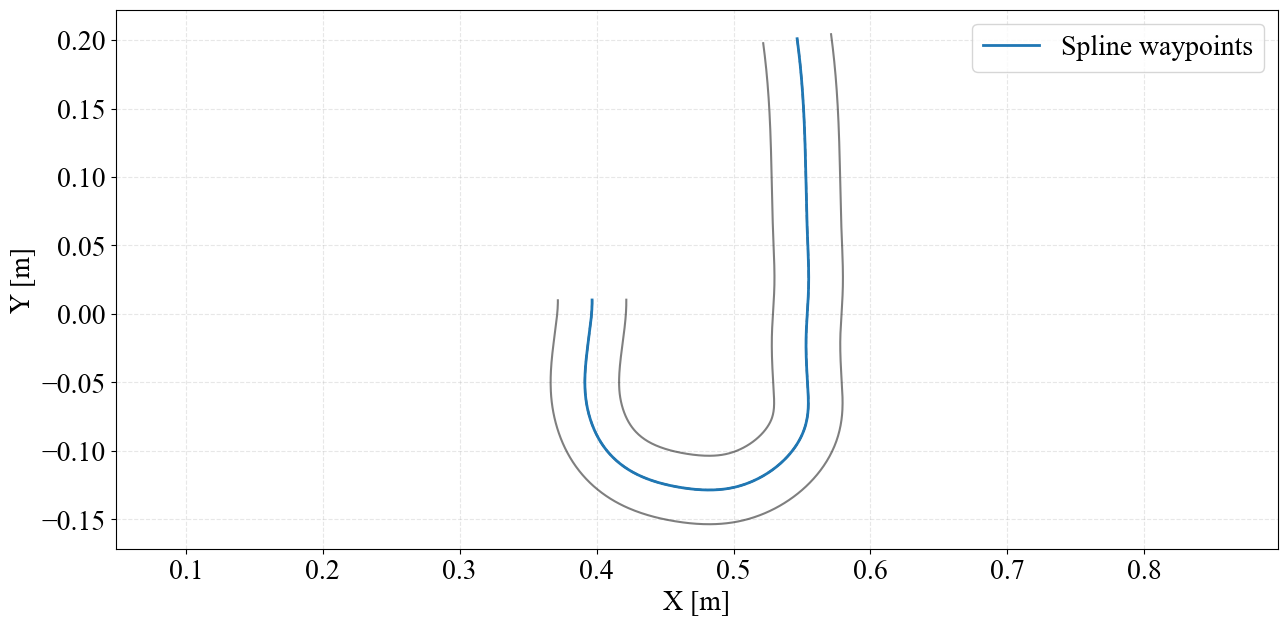

In [30]:
WP = WayPoint(
    waypoints=waypoints[:, :2], 
    waypoint_density=1000.,
    smoothness_params = np.full(2, 5e-4),
    waypoints_width=5e-2,
    plot_waypoints_flag=True
)

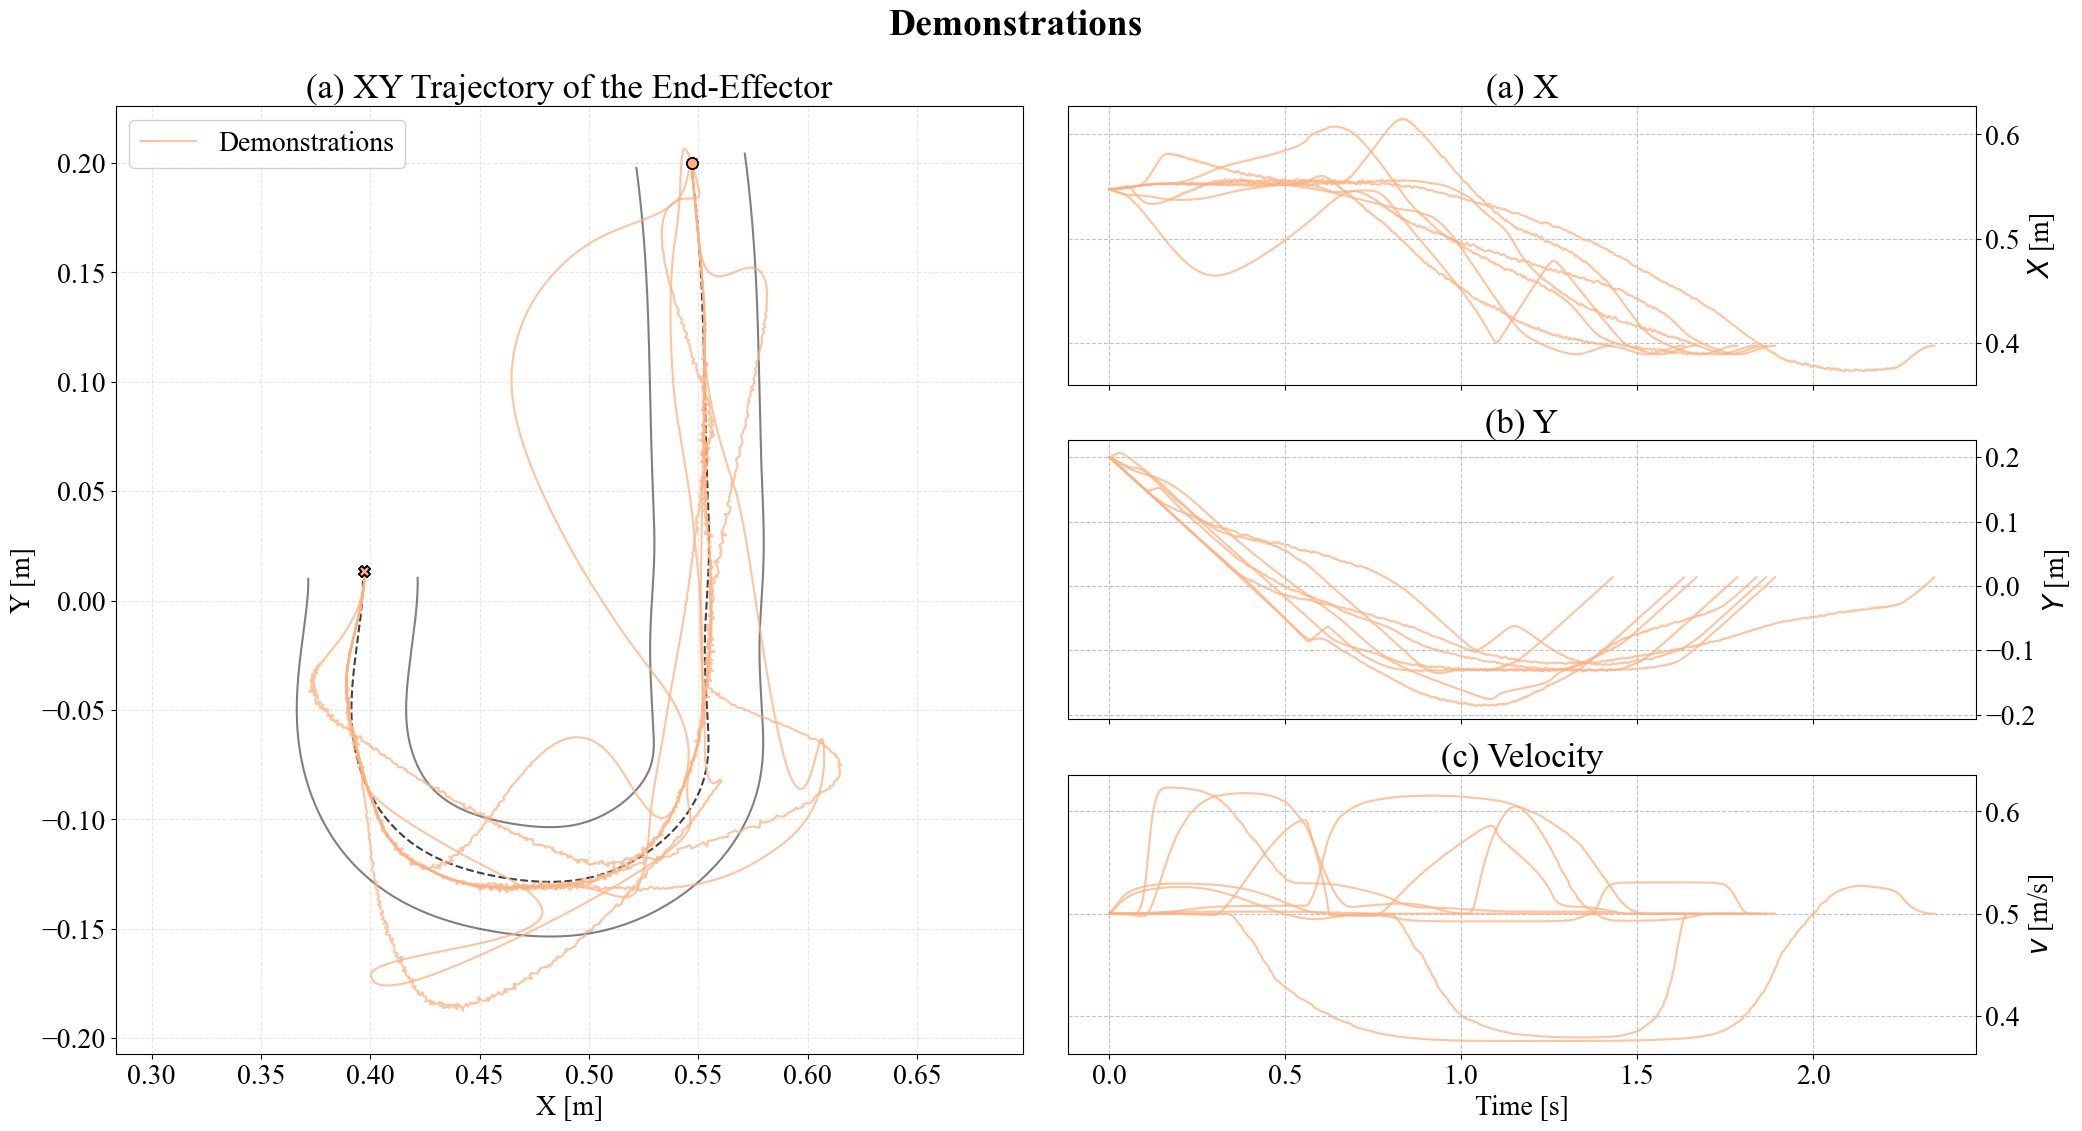

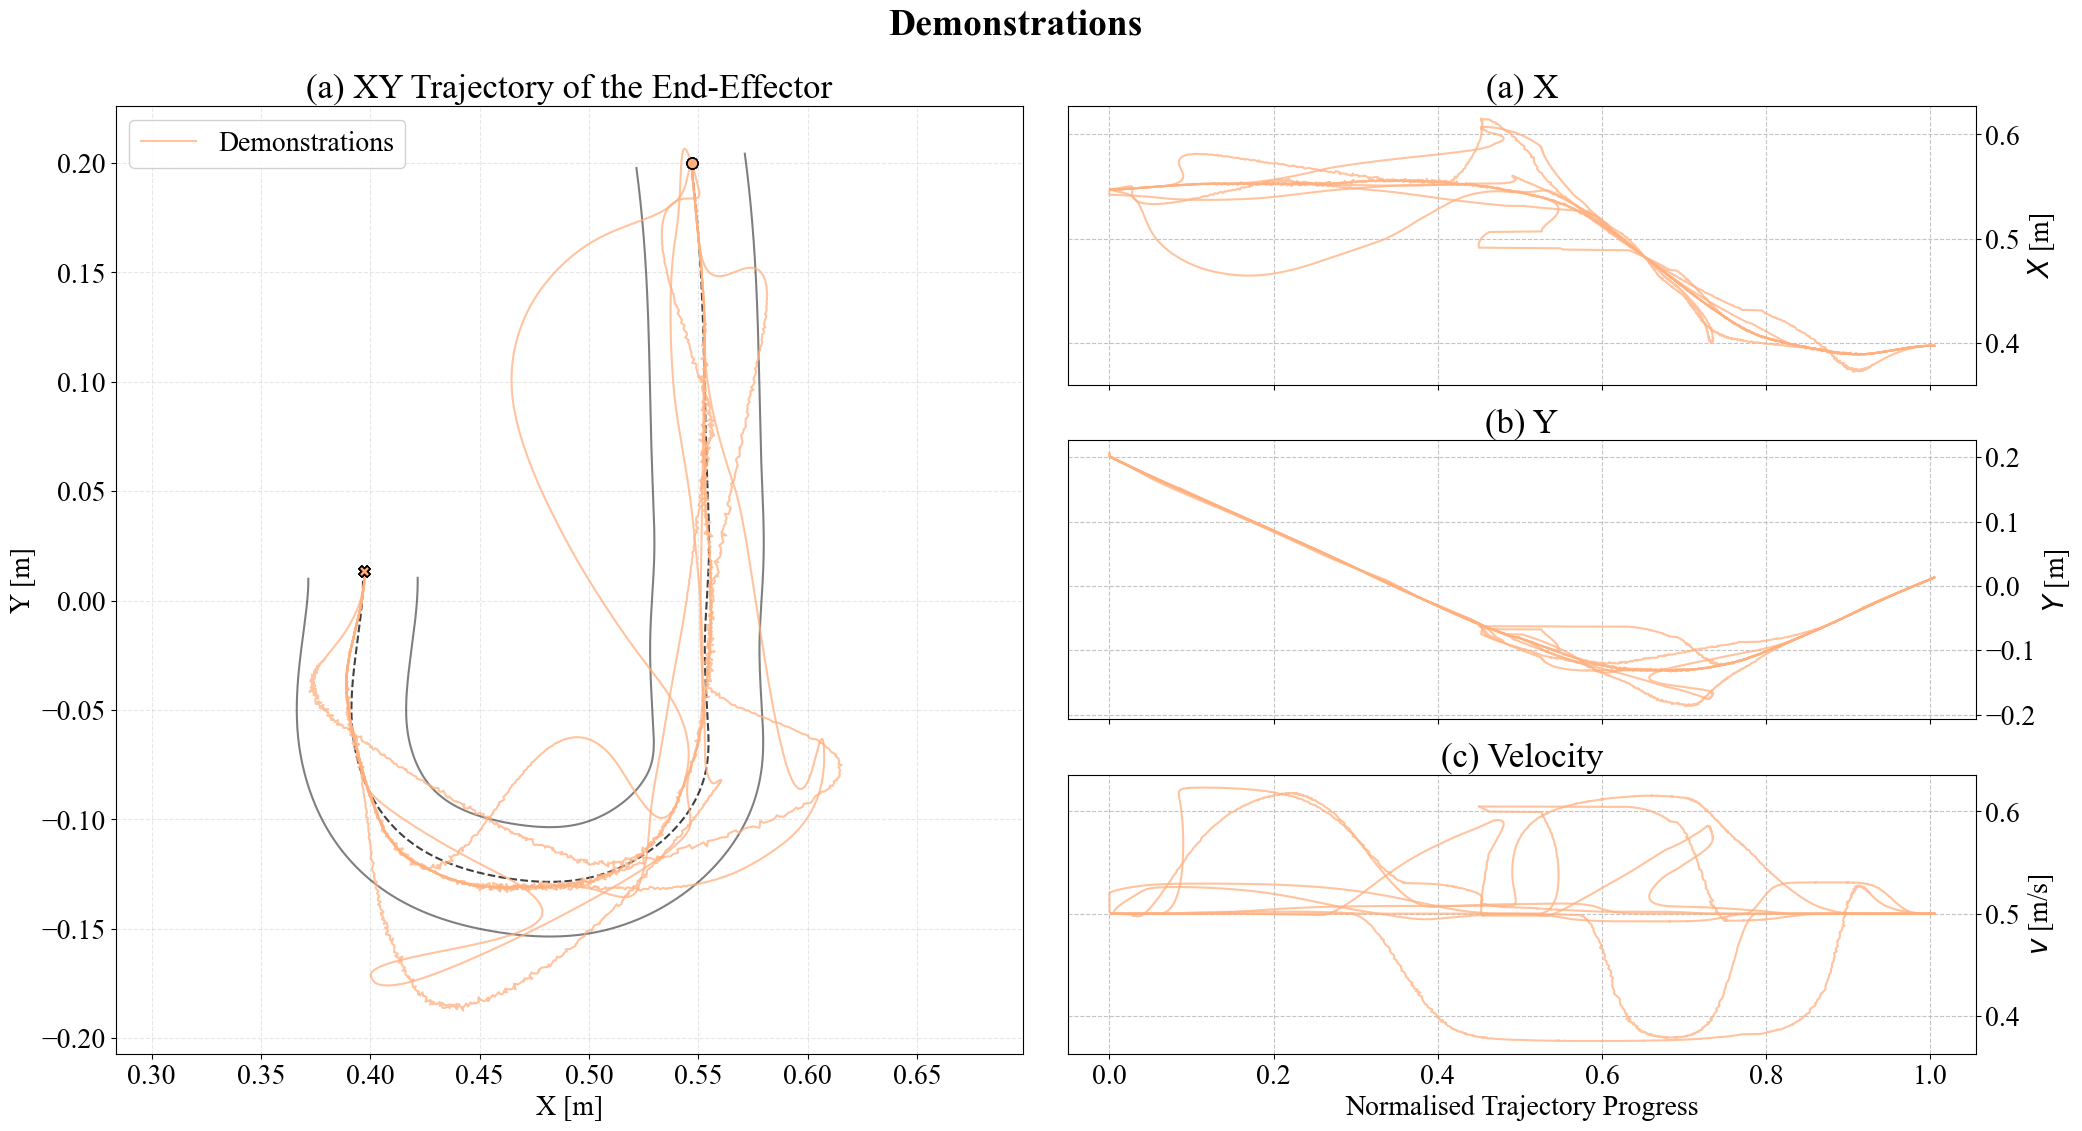

In [31]:
for TD in TDList_Demo:
    TD['progress'], nearest_waypoints = WP.find_progress_value(TD['states'][:, :2]) 
    TD['deviations'] = np.linalg.norm(
        nearest_waypoints - TD['states'][:, :2], axis=-1
    )

plot_trajectory_data(
    waypoints=WP.waypoints,
    waypoints_width=WP.waypoints_width,
    TDList_demo=TDList_Demo, 
    TD_demo_name="Demonstrations",
    TD_learnt_name="", 
    filedate=f"{FILEDATE}_Time_",
)
plot_trajectory_data(
    waypoints=WP.waypoints,
    waypoints_width=WP.waypoints_width,
    TDList_demo=TDList_Demo, 
    TD_demo_name="Demonstrations",
    filedate=f"{FILEDATE}_Progress_",
    TD_learnt_name="", 
    x_axis_time=False, 
)

In [32]:
for TD in TDList_Demo:
    TD['states'] *= 15.
    TD['t_steps'] *= 3.
    TD["deviations"] *= 15.

In [33]:
WP.waypoints *= 15.
WP.waypoints_width *= 15.
WP.cumulative_dists *= 15.

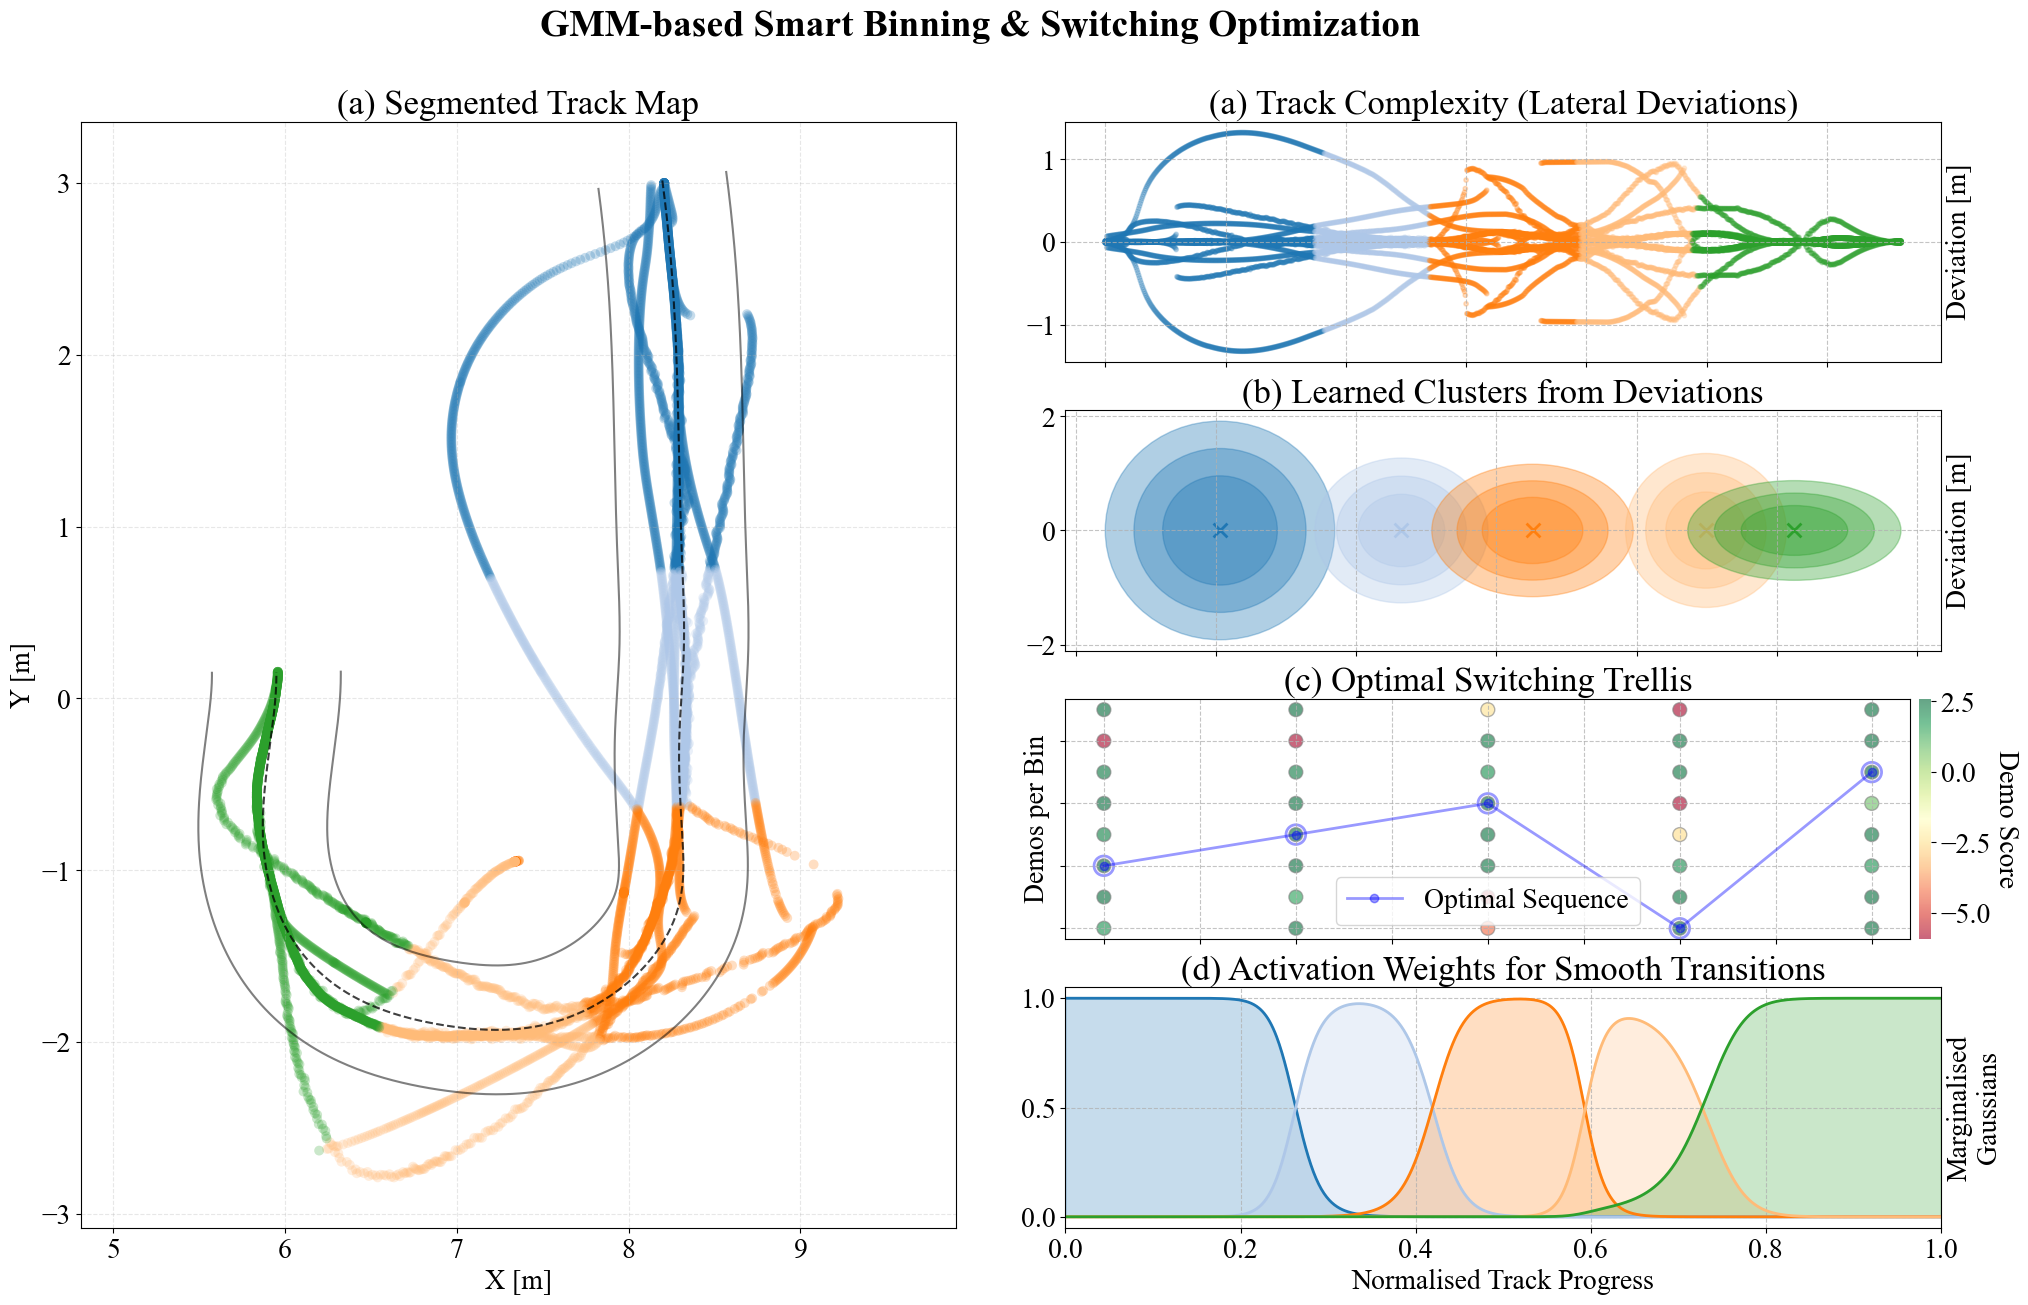

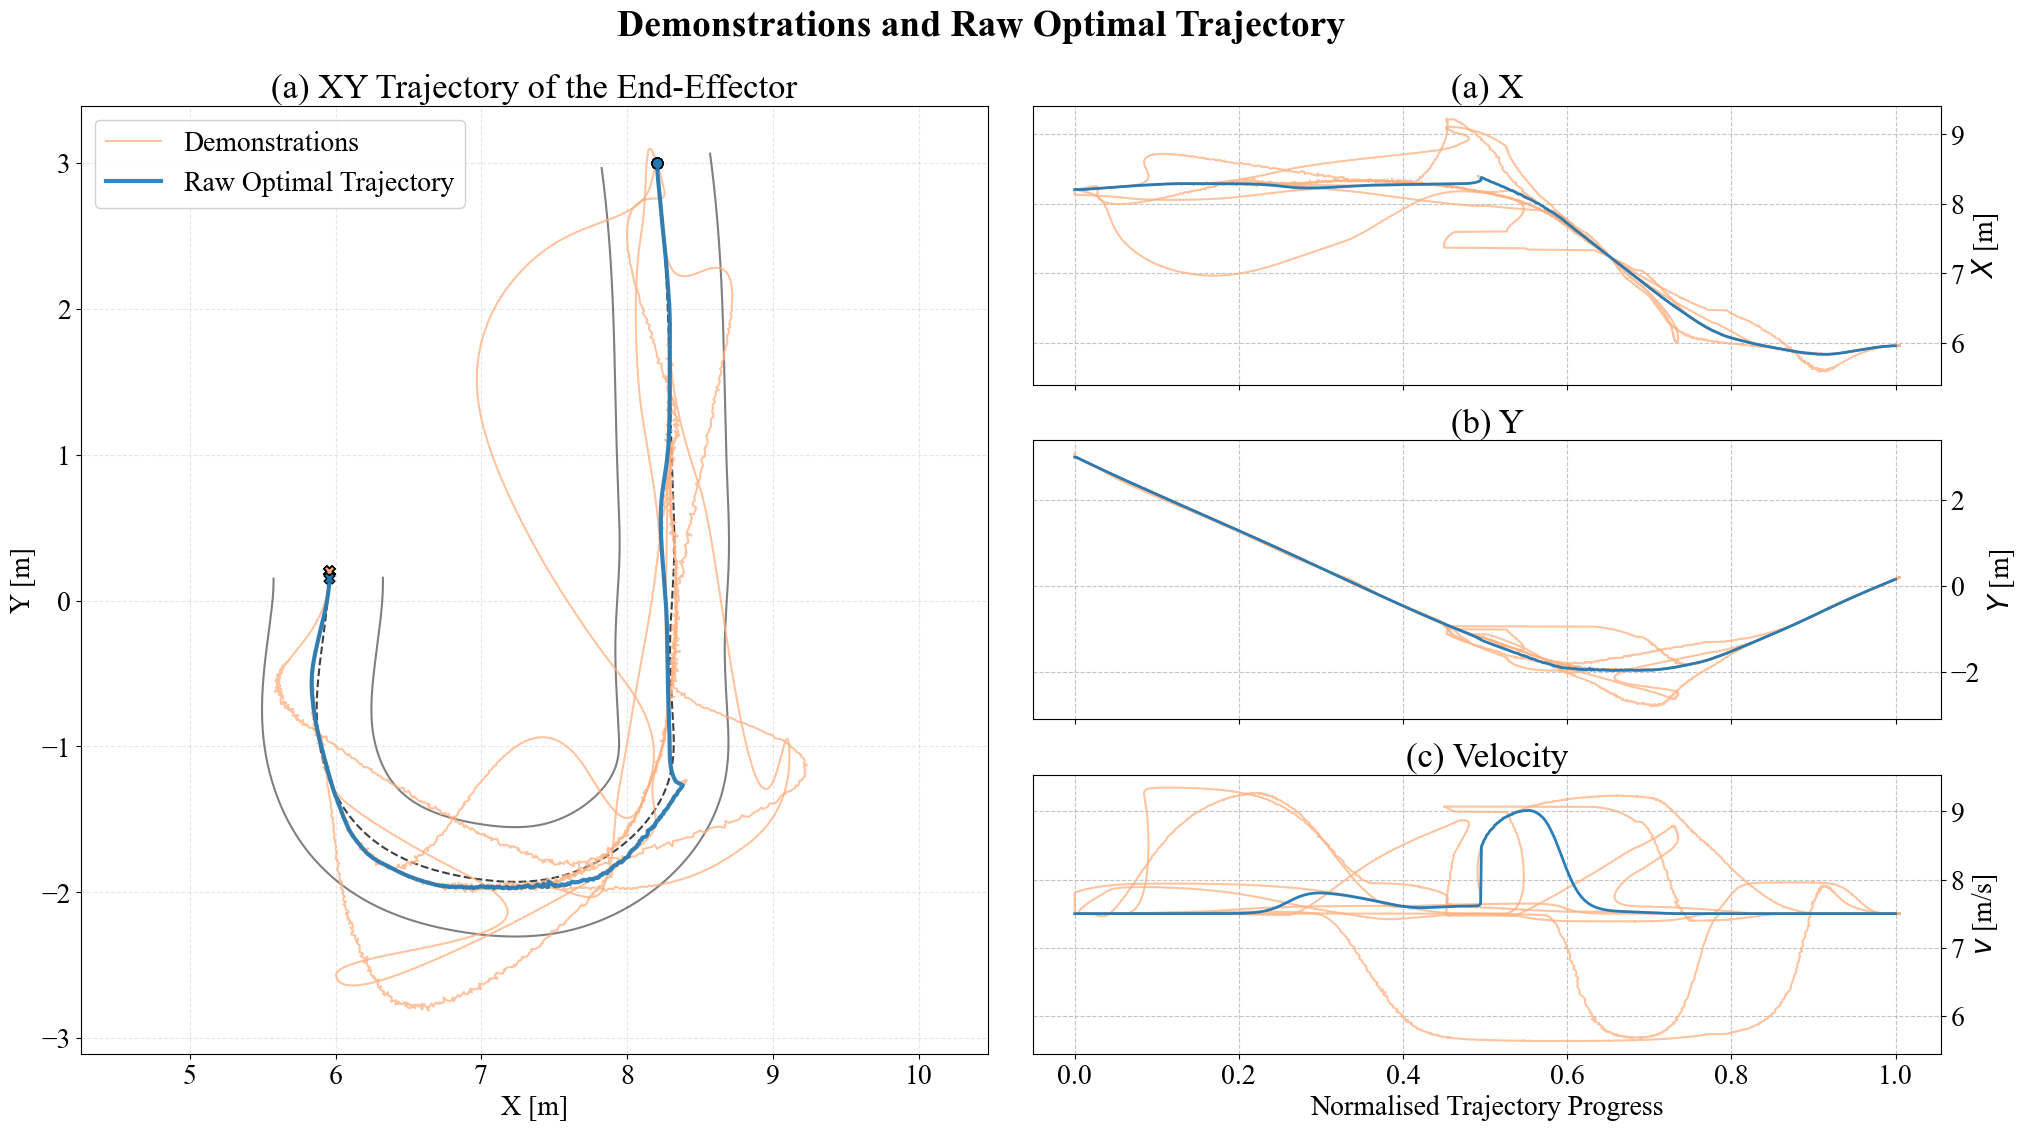

In [ ]:
TDOpt = generate_opt_trajectory(
    TDList=TDList_Demo, 
    num_segs=5,
    acceleration_max=0.5,
    safety_width=2e-2,
    safety_gain=25.,
    switch_gain=50.,
    filedate=f"{FILEDATE}_MERGE",
    track_length=WP.cumulative_dists[-1],
    waypoints_plotter=partial(plot_waypoints, WP.waypoints, WP.waypoints_width),
)

plot_trajectory_data(
    waypoints=WP.waypoints,
    waypoints_width=WP.waypoints_width,
    TDList_learnt=[TDOpt], 
    TDList_demo=TDList_Demo,
    TD_demo_name="Demonstrations",
    TD_learnt_name="Raw Optimal Trajectory", 
    x_axis_time=False, 
    filedate=f"{FILEDATE}_MERGE",
)

In [16]:
WP_og = WayPoint( 
    path_to_waypts=join("data_dummy", f"WayPoints_{FILEDATE}.txt"),
    waypoint_density=1000.,
    smoothness_params = np.full(2, 5e-4),
    waypoints_width=5e-2
)

SC = SwitchingController(
    states=TDOpt['states'],
    progress=TDOpt['progress'],
    smoothness_params=[2e-3, 2e-3, 2e-3, 2e-3],
)

In [17]:
TDList_Learnt = rollout_switching_controller(
    TDList_Demo, TDOpt, WP, WP_og, SC, dt=5e-3, num_exps=5
)

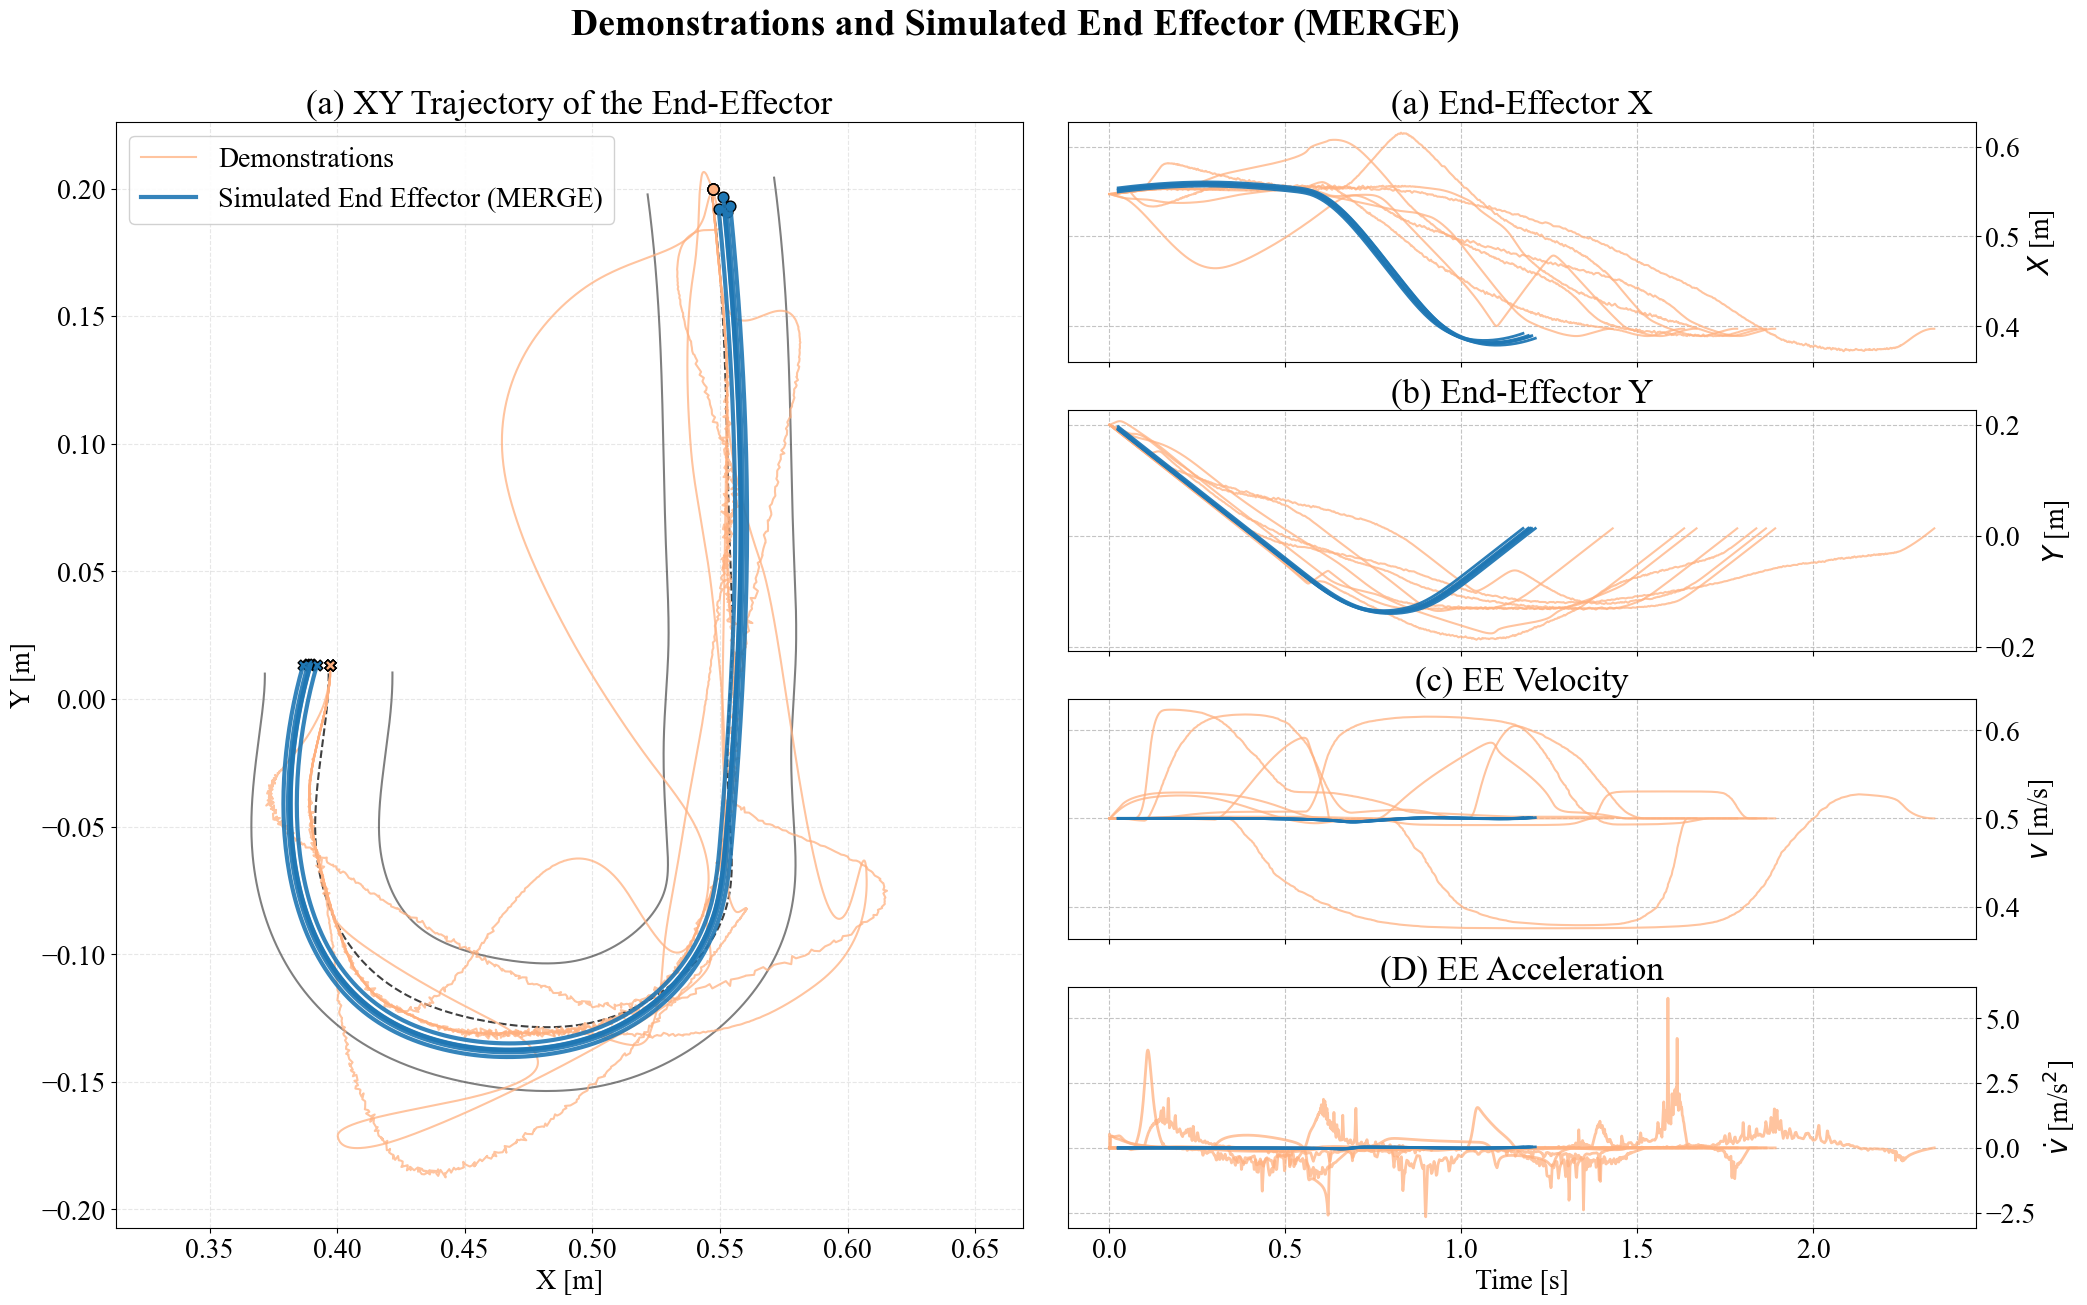

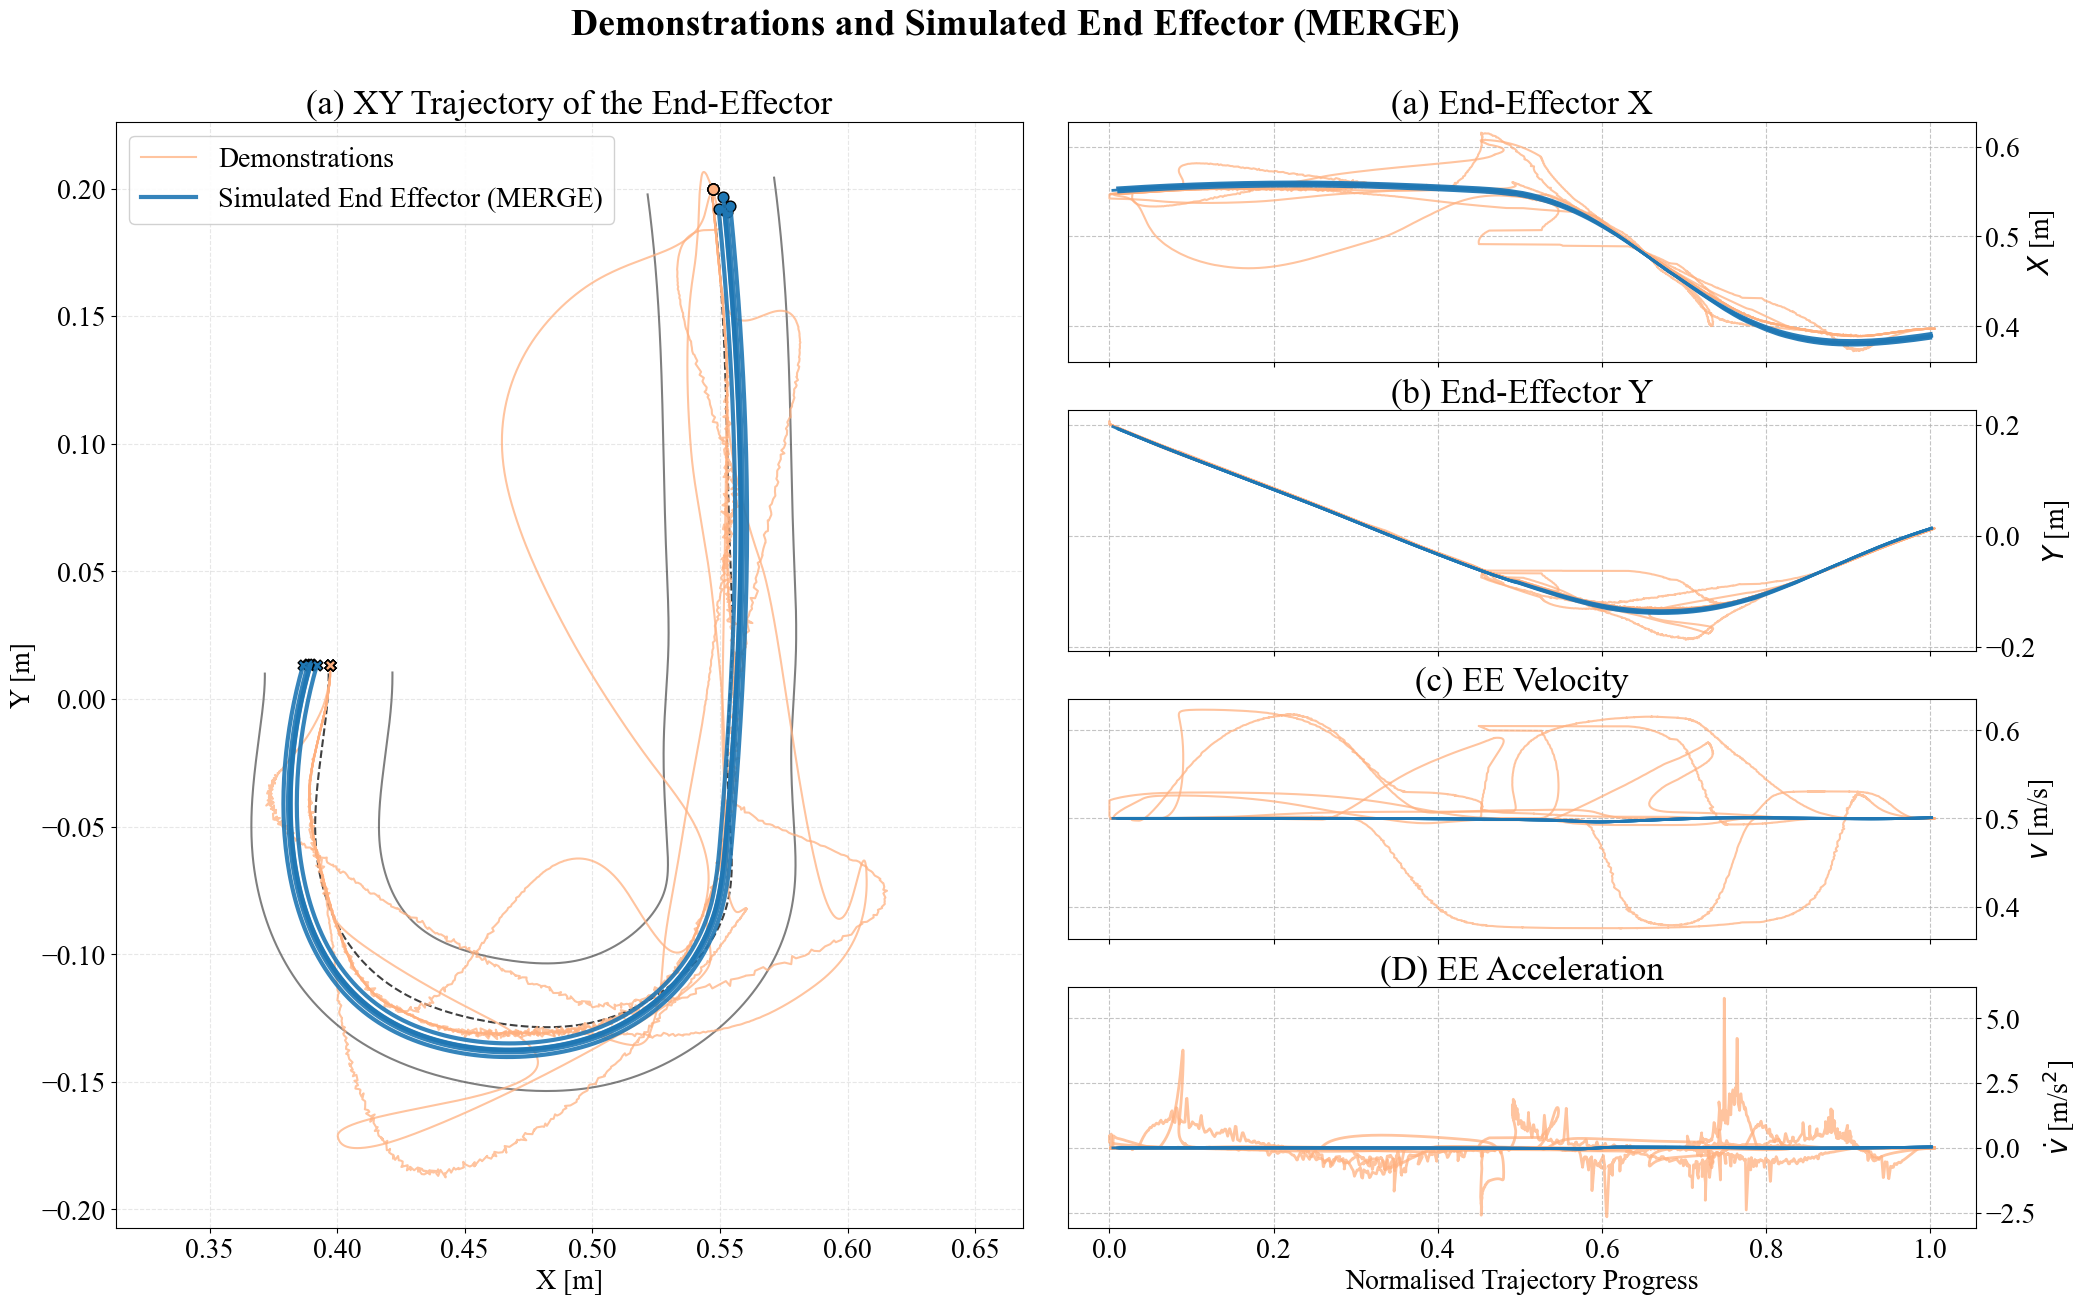

In [18]:
plot_trajectory_data(
    waypoints=WP.waypoints,
    waypoints_width=WP.waypoints_width,
    TDList_learnt=TDList_Learnt, 
    plot_state_dot_indices=[3],
    TDList_demo=TDList_Demo, 
    TD_demo_name="Demonstrations",
    TD_learnt_name="Simulated End Effector (MERGE)", 
    filedate=f"{FILEDATE}_MERGE"
)

plot_trajectory_data(
    waypoints=WP.waypoints,
    waypoints_width=WP.waypoints_width,
    TDList_learnt=TDList_Learnt, 
    TDList_demo=TDList_Demo, 
    plot_state_dot_indices=[3],
    TD_demo_name="Demonstrations",
    TD_learnt_name="Simulated End Effector (MERGE)", 
    x_axis_time=False, 
    filedate=f"{FILEDATE}_MERGE"
)

In [19]:
save_traj_data(
    TDList=TDList_Learnt, 
    filepath=join("data_dummy", f"TDList_Learnt_{FILEDATE}_MERGE.pkl")
)

[INFO]: Trajectory Data saved succesfully -> data_dummy\TDList_Learnt_J_MERGE.pkl
